<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**


## **Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений**



* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)



 **Конечный выбор датасета осуществляется по Вашему желанию (хорошо, если это будут Ваши датасеты), учитывая рекомендации приведенные выше.**


**1.1. Загрузка и подготовка данных**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Обучающая выборка: (50000, 32, 32, 3)
Тестовая выборка: (10000, 32, 32, 3)


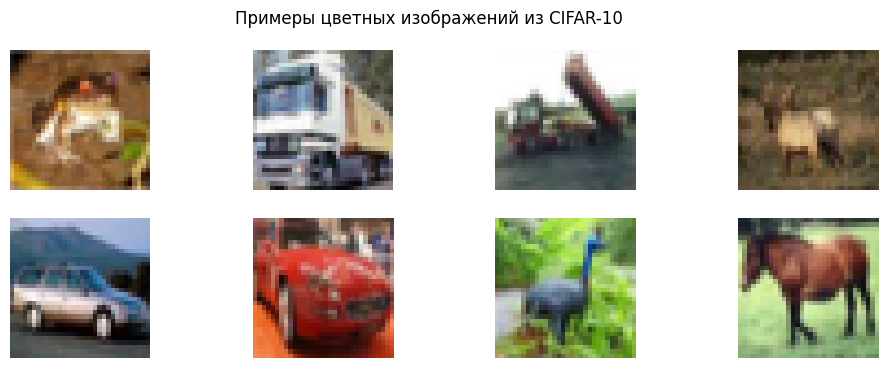

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
import tensorflow_datasets as tfds

# Загружаем CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Нормализуем значения пикселей [0, 255] -> [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# Покажем несколько примеров
plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.suptitle('Примеры цветных изображений из CIFAR-10')
plt.show()

**1.2. Преобразование RGB в оттенки серого**

Черно-белые изображения (вход): (50000, 32, 32, 1)
Цветные изображения (выход): (50000, 32, 32, 3)


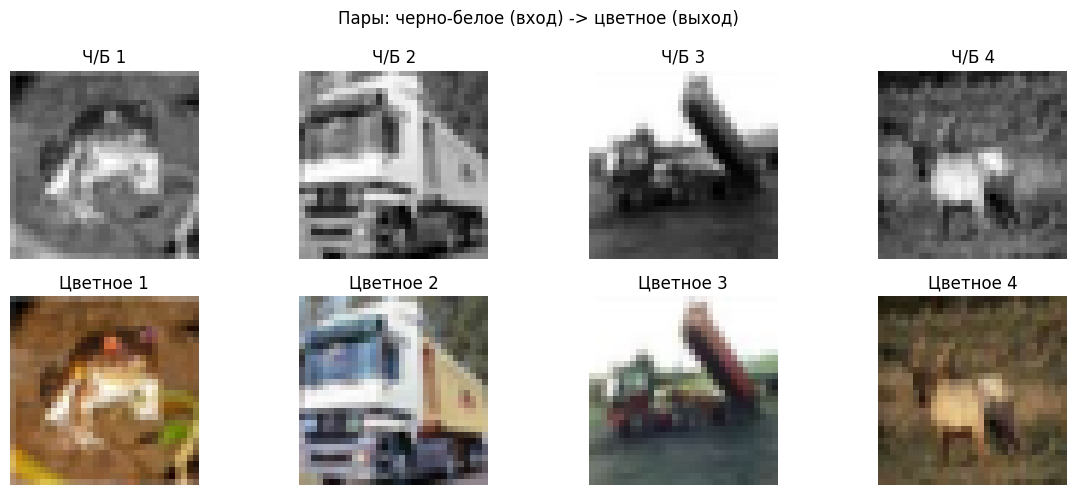

In [ ]:
def rgb_to_grayscale(images):
    # Формула: Y = 0.299*R + 0.587*G + 0.114*B
    grayscale = 0.299 * images[:,:,:,0] + 0.587 * images[:,:,:,1] + 0.114 * images[:,:,:,2]
    # Добавляем размерность канала
    grayscale = np.expand_dims(grayscale, axis=-1)
    return grayscale

# Создаем черно-белые изображения (вход для автоэнкодера)
X_train_gray = rgb_to_grayscale(X_train)
X_test_gray = rgb_to_grayscale(X_test)

print(f"Черно-белые изображения (вход): {X_train_gray.shape}")
print(f"Цветные изображения (выход): {X_train.shape}")

# Визуализируем пары
plt.figure(figsize=(12, 5))
for i in range(4):
    # Черно-белое
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train_gray[i].squeeze(), cmap='gray')
    plt.title(f'Ч/Б {i+1}')
    plt.axis('off')

    # Цветное
    plt.subplot(2, 4, i+5)
    plt.imshow(X_train[i])
    plt.title(f'Цветное {i+1}')
    plt.axis('off')
plt.suptitle('Пары: черно-белое (вход) -> цветное (выход)')
plt.tight_layout()
plt.show()

**1.3. Архитектура автоэнкодера**

In [ ]:
def build_colorization_autoencoder(input_shape=(32, 32, 1)):
    # Энкодер
    encoder_input = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Декодер
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(encoder_input, decoder_output)
    return model

# Создаем модель
autoencoder = build_colorization_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,379 (1.27 MB)

 Trainable params: 333,379 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**1.4. Компиляция и обучение**

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error для сравнения цветов
    metrics=['mae']
)

# Уменьшаем выборку для ускорения обучения (берем 10000 изображений)
X_train_small = X_train[:10000]
X_train_gray_small = X_train_gray[:10000]

# Обучение
history_color = autoencoder.fit(
    X_train_gray_small, X_train_small,
    validation_split=0.2,
    epochs=20,
    batch_size=8,
    verbose=1
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0194 - mae: 0.1041 - val_loss: 0.0147 - val_mae: 0.0901
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0138 - mae: 0.0869 - val_loss: 0.0137 - val_mae: 0.0865
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0124 - mae: 0.0822 - val_loss: 0.0118 - val_mae: 0.0799
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0116 - mae: 0.0793 - val_loss: 0.0121 - val_mae: 0.0812
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0111 - mae: 0.0772 - val_loss: 0.0107 - val_mae: 0.0756
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0107 - mae: 0.0756 - val_loss: 0.0106 - val_mae: 0.0757
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0103 - mae: 0.0744 - val_loss: 0.0109 - val_mae: 0.0771
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0101 - mae: 0.0735 - val_loss: 0.0101 - val_mae: 0.0729
Epoch 9/20
1000/1000 ━━━━━━━━━━━━━━━━━━

**1.5. Визуализация результатов обучения**

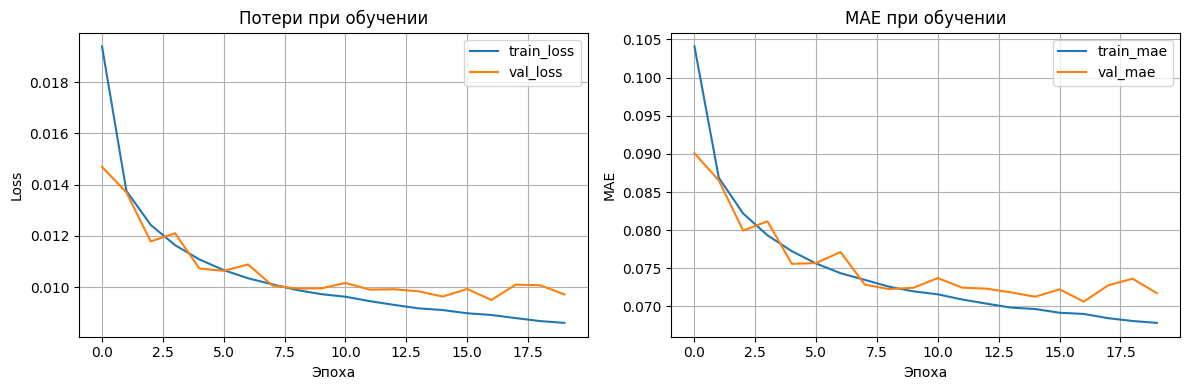

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_color.history['loss'], label='train_loss')
plt.plot(history_color.history['val_loss'], label='val_loss')
plt.title('Потери при обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_color.history['mae'], label='train_mae')
plt.plot(history_color.history['val_mae'], label='val_mae')
plt.title('MAE при обучении')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**1.6. Тестирование модели на новых изображениях**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


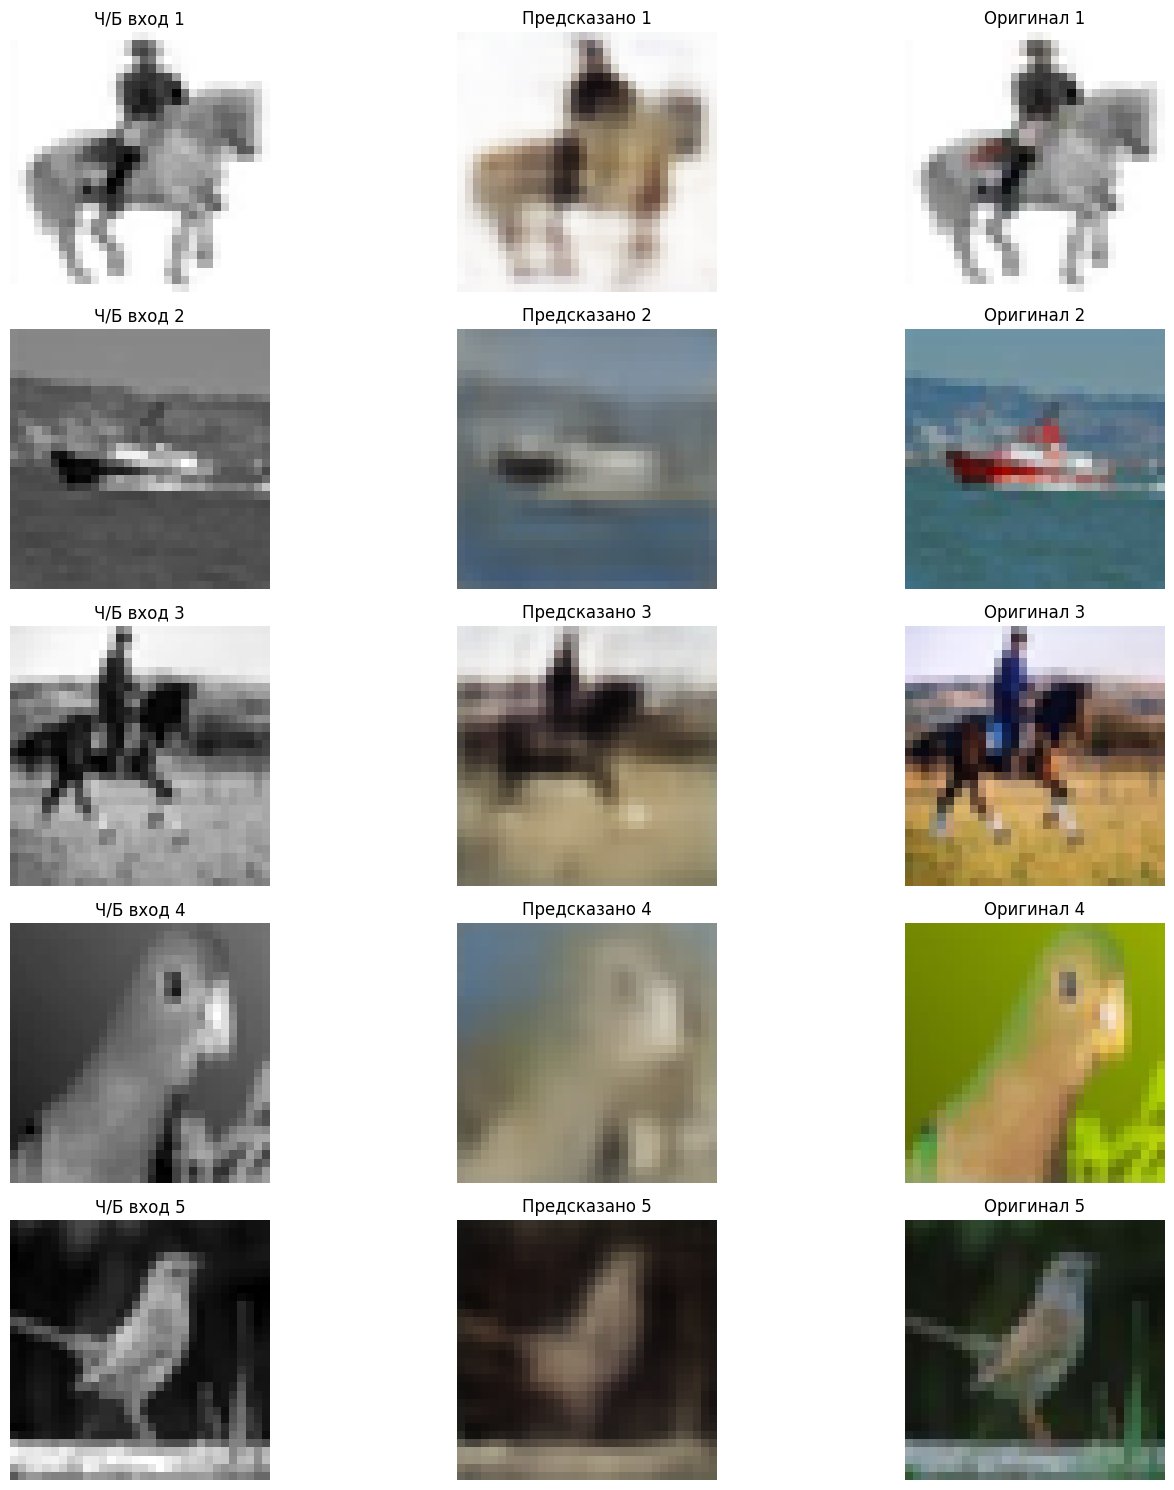

In [ ]:
# Берем несколько изображений из тестовой выборки
n_samples = 5
test_indices = np.random.choice(len(X_test), n_samples, replace=False)

# Предсказываем цвета
X_test_gray_sample = X_test_gray[test_indices]
pred_colors = autoencoder.predict(X_test_gray_sample)

# Визуализация
plt.figure(figsize=(15, n_samples * 3))
for i, idx in enumerate(test_indices):
    # Черно-белое (вход)
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test_gray[idx].squeeze(), cmap='gray')
    plt.title(f'Ч/Б вход {i+1}')
    plt.axis('off')

    # Предсказанное цветное
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(pred_colors[i])
    plt.title(f'Предсказано {i+1}')
    plt.axis('off')

    # Оригинальное цветное
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(X_test[idx])
    plt.title(f'Оригинал {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях**



1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

**2.1. Загрузка датасета**

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Нормализация
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Обучающая: {X_train.shape}")
print(f"Тестовая: {X_test.shape}")

Обучающая: (50000, 32, 32, 3)
Тестовая: (10000, 32, 32, 3)


**2.2. Добавление шума к изображениям**

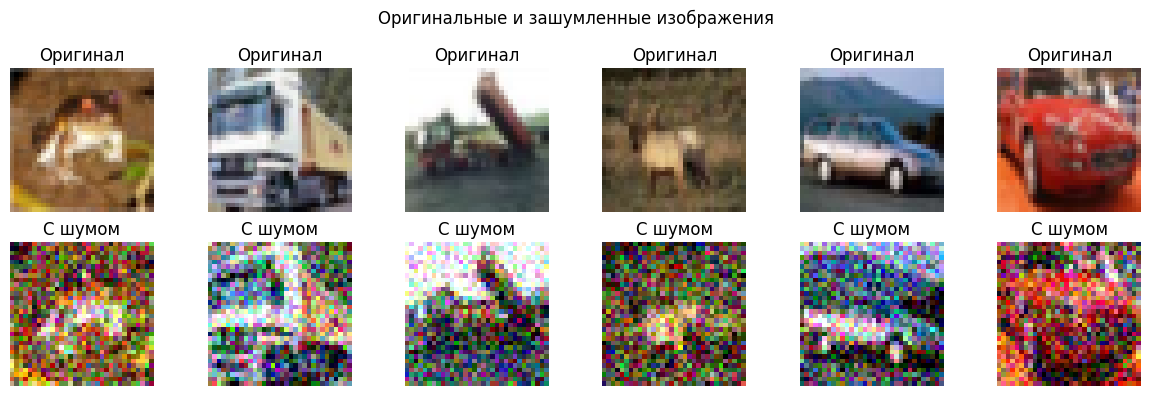

In [ ]:
def add_gaussian_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

# Создаем зашумленные версии
X_train_noisy = add_gaussian_noise(X_train)
X_test_noisy = add_gaussian_noise(X_test)

# Визуализируем
plt.figure(figsize=(12, 4))
for i in range(6):
    # Оригинал
    plt.subplot(2, 6, i+1)
    plt.imshow(X_train[i])
    plt.title('Оригинал')
    plt.axis('off')

    # Зашумленный
    plt.subplot(2, 6, i+7)
    plt.imshow(X_train_noisy[i])
    plt.title('С шумом')
    plt.axis('off')
plt.suptitle('Оригинальные и зашумленные изображения')
plt.tight_layout()
plt.show()

**2.3. Создание архитектуры автоэнкодера для удаления шума**

In [ ]:
def build_denoising_autoencoder(input_shape=(32, 32, 3)):
    # Энкодер
    input_img = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Декодер
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    return model

denoiser = build_denoising_autoencoder()
denoiser.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**2.4. Компиляция и обучение**

In [ ]:
denoiser.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Берем часть данных для ускорения
X_train_small = X_train[:10000]
X_train_noisy_small = X_train_noisy[:10000]

# Обучение
history_denoise = denoiser.fit(
    X_train_noisy_small, X_train_small,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0188 - mae: 0.1012 - val_loss: 0.0098 - val_mae: 0.0744
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0089 - mae: 0.0702 - val_loss: 0.0085 - val_mae: 0.0687
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0077 - mae: 0.0654 - val_loss: 0.0071 - val_mae: 0.0626
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0071 - mae: 0.0629 - val_loss: 0.0068 - val_mae: 0.0609
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0067 - mae: 0.0610 - val_loss: 0.0069 - val_mae: 0.0619
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0064 - mae: 0.0594 - val_loss: 0.0068 - val_mae: 0.0618
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0063 - mae: 0.0589 - val_loss: 0.0061 - val_mae: 0.0578
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0060 - mae: 0.0575 - val_loss: 0.0059 - val_mae: 0.0565
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/

**2.5. Визуализация результатов**

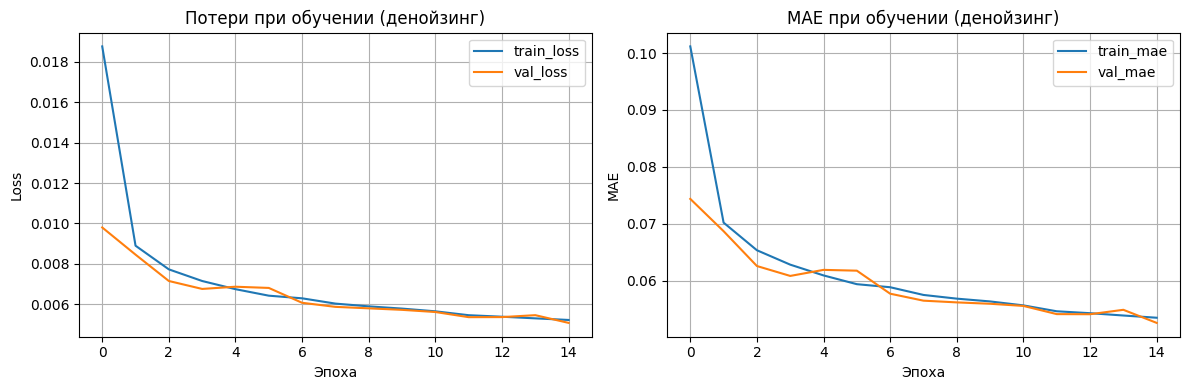

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step


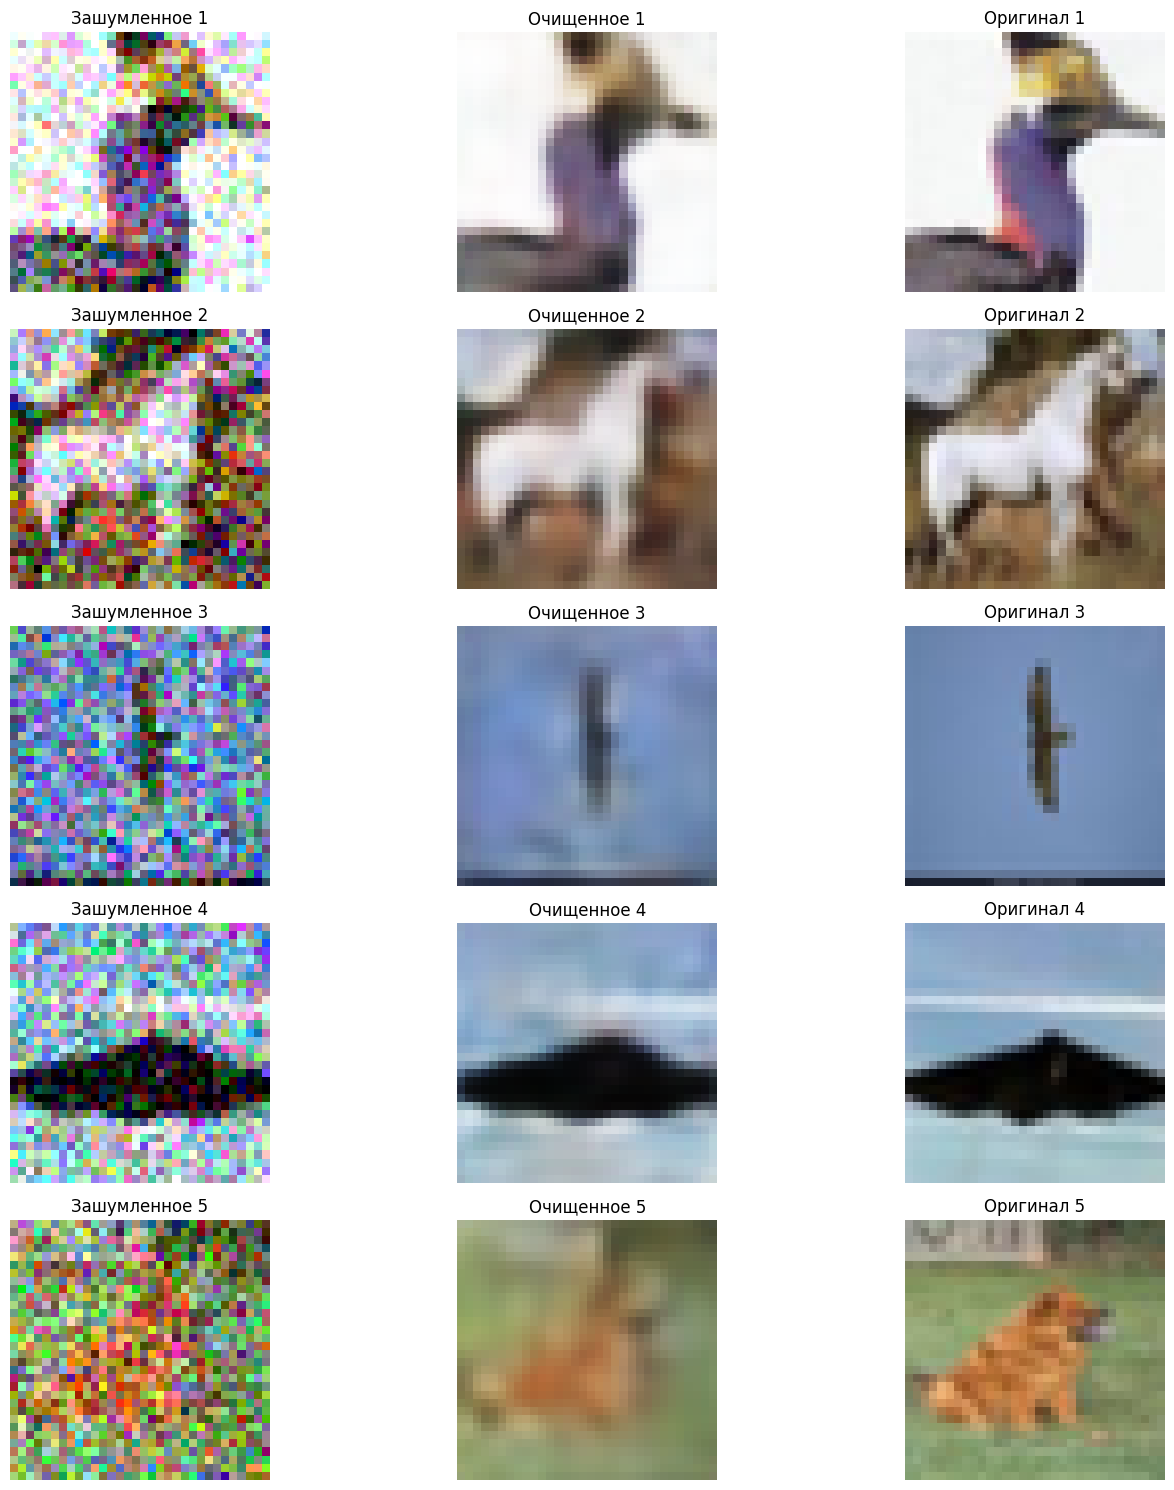

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_denoise.history['loss'], label='train_loss')
plt.plot(history_denoise.history['val_loss'], label='val_loss')
plt.title('Потери при обучении (денойзинг)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_denoise.history['mae'], label='train_mae')
plt.plot(history_denoise.history['val_mae'], label='val_mae')
plt.title('MAE при обучении (денойзинг)')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Тестирование
n_samples = 5
test_indices = np.random.choice(len(X_test), n_samples, replace=False)

# Предсказания
X_test_noisy_sample = X_test_noisy[test_indices]
denoised = denoiser.predict(X_test_noisy_sample)

# Визуализация
plt.figure(figsize=(15, n_samples * 3))
for i, idx in enumerate(test_indices):
    # Зашумленное
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test_noisy[idx])
    plt.title(f'Зашумленное {i+1}')
    plt.axis('off')

    # Очищенное (предсказание)
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(denoised[i])
    plt.title(f'Очищенное {i+1}')
    plt.axis('off')

    # Оригинал
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(X_test[idx])
    plt.title(f'Оригинал {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))**



1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

**3.1. Установка всего нужного**

In [1]:
!pip install kagglehub -q

import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
import os
from PIL import Image
from tqdm import tqdm
import cv2

print("Библиотеки загружены")

Библиотеки загружены


**3.2. Скачивание датасета**

In [3]:
# Скачивание датасета
print("Загрузка датасета Nature...")
path = kagglehub.dataset_download("heyitsfahd/nature")
print("Путь к датасету:", path)

# Функция для просмотра структуры папок
def print_structure(dir_path, indent=0):
    try:
        items = os.listdir(dir_path)
        for item in sorted(items)[:15]:  # Показываем первые 15
            item_path = os.path.join(dir_path, item)
            if os.path.isdir(item_path):
                print("  " * indent + f"{item}/")
                print_structure(item_path, indent + 1)
            else:
                if item.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    print("  " * indent + f"{item}")
    except:
        pass

print("\nСтруктура датасета:")
print_structure(path)

Загрузка датасета Nature...
Путь к датасету: /root/.cache/kagglehub/datasets/heyitsfahd/nature/versions/1

Структура датасета:
Nature/
  x128/
    City/
      1.jpg
      10.jpg
      100.jpg
      1000.jpg
      10000.jpg
      10001.jpg
      10002.jpg
      10003.jpg
      10004.jpg
      10005.jpg
      10006.jpg
      10007.jpg
      10008.jpg
      10009.jpg
      1001.jpg
    Fire/
      1.jpg
      10.jpg
      100.jpg
      1000.jpg
      10000.jpg
      10001.jpg
      10002.jpg
      10003.jpg
      10004.jpg
      10005.jpg
      10006.jpg
      10007.jpg
      10008.jpg
      10009.jpg
      1001.jpg
    Lake/
      1.jpg
      10.jpg
      100.jpg
      1000.jpg
      10000.jpg
      10001.jpg
      10002.jpg
      10003.jpg
      10004.jpg
      10005.jpg
      10006.jpg
      10007.jpg
      10008.jpg
      10009.jpg
      1001.jpg
    Mountain/
      1.jpg
      10.jpg
      100.jpg
      1000.jpg
      10000.jpg
      10001.jpg
      10002.jpg
      10003.jpg
      10

In [6]:
# Параметры
IMG_HIGH = 128   # ВЫХОД: четкое 128x128
IMG_LOW = 64     # ВХОД: низкое 64x64 (из папки x64)
N_SAMPLES = 500  # Количество изображений

# Указываем папки для Lake
BASE_PATH = path
HIGH_RES_PATH = os.path.join(BASE_PATH, 'Nature', 'x128', 'Lake')
LOW_RES_PATH = os.path.join(BASE_PATH, 'Nature', 'x64', 'Lake')


print(f"Вход модели: {IMG_LOW}x{IMG_LOW} (из папки x64/Lake)")
print(f"Выход модели: {IMG_HIGH}x{IMG_HIGH} (из папки x128/Lake)")
print(f"Количество изображений: {N_SAMPLES}")
print(f"\nПуть к высокому разрешению: {HIGH_RES_PATH}")
print(f" Путь к низкому разрешению: {LOW_RES_PATH}")

# Проверяем существование папок
if not os.path.exists(HIGH_RES_PATH):
    print(f"\n Папка не найдена: {HIGH_RES_PATH}")
    print("Проверьте структуру датасета:")
    print_structure(BASE_PATH)
else:
    print(f"\nПапки найдены!")

# Функция загрузки изображений из папки
def load_images_from_folder(folder, target_size, max_images=500):
    """Загружает изображения из папки"""
    images = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

    files = [f for f in os.listdir(folder) if f.lower().endswith(valid_extensions)]
    print(f"  Найдено файлов в {os.path.basename(folder)}: {len(files)}")

    if max_images and len(files) > max_images:
        files = files[:max_images]
        print(f"  Используем {max_images} изображений")

    for file in tqdm(files, desc=f"Загрузка {os.path.basename(folder)}"):
        img_path = os.path.join(folder, file)
        try:
            img = Image.open(img_path)
            if img.mode != 'RGB':
                img = img.convert('RGB')
            img = img.resize(target_size, Image.LANCZOS)
            images.append(np.array(img) / 255.0)
        except Exception as e:
            continue

    return np.array(images)

Вход модели: 64x64 (из папки x64/Lake)
Выход модели: 128x128 (из папки x128/Lake)
Количество изображений: 500

Путь к высокому разрешению: /root/.cache/kagglehub/datasets/heyitsfahd/nature/versions/1/Nature/x128/Lake
 Путь к низкому разрешению: /root/.cache/kagglehub/datasets/heyitsfahd/nature/versions/1/Nature/x64/Lake

Папки найдены!


In [7]:
# Загружаем высокое разрешение (128x128) - ЦЕЛЬ
print("\n📥 Загрузка высокого разрешения (цель)...")
X_high = load_images_from_folder(HIGH_RES_PATH, (IMG_HIGH, IMG_HIGH), N_SAMPLES)

# Загружаем низкое разрешение (64x64) - ВХОД
print("\n📥 Загрузка низкого разрешения (вход)...")
X_low = load_images_from_folder(LOW_RES_PATH, (IMG_LOW, IMG_LOW), N_SAMPLES)

# Выравниваем количество (берем минимум)
min_len = min(len(X_high), len(X_low))
X_high = X_high[:min_len]
X_low = X_low[:min_len]

print(f"\nЗагружено {len(X_high)} пар изображений Lake")
print(f"   ВХОД (низкое разрешение): {X_low.shape}")   # (N, 64, 64, 3)
print(f"   ВЫХОД (высокое разрешение): {X_high.shape}")  # (N, 128, 128, 3)


📥 Загрузка высокого разрешения (цель)...
  Найдено файлов в Lake: 25236
  Используем 500 изображений


Загрузка Lake: 100%|██████████| 500/500 [00:00<00:00, 985.10it/s] 



📥 Загрузка низкого разрешения (вход)...
  Найдено файлов в Lake: 25236
  Используем 500 изображений


Загрузка Lake: 100%|██████████| 500/500 [00:00<00:00, 2104.02it/s]


Загружено 500 пар изображений Lake
   ВХОД (низкое разрешение): (500, 64, 64, 3)
   ВЫХОД (высокое разрешение): (500, 128, 128, 3)


**3.3. Создание пар для чего-то там**

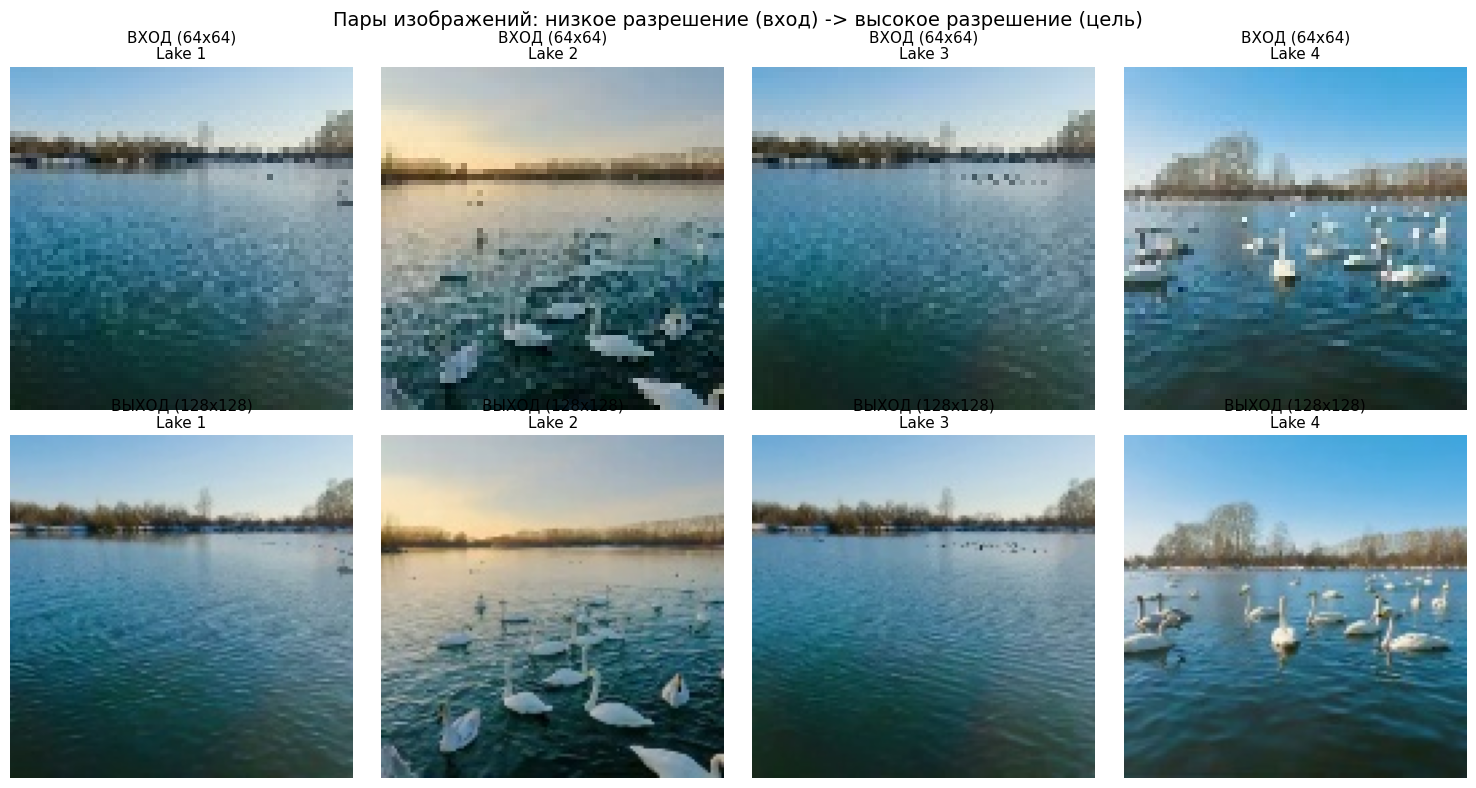

In [8]:
# Показываем примеры пар
plt.figure(figsize=(15, 8))

for i in range(min(4, len(X_low))):
    # Вход (64x64)
    plt.subplot(2, 4, i+1)
    plt.imshow(X_low[i])
    plt.title(f'ВХОД (64x64)\nLake {i+1}', fontsize=11)
    plt.axis('off')

    # Выход (128x128)
    plt.subplot(2, 4, i+5)
    plt.imshow(X_high[i])
    plt.title(f'ВЫХОД (128x128)\nLake {i+1}', fontsize=11)
    plt.axis('off')

plt.suptitle('Пары изображений: низкое разрешение (вход) -> высокое разрешение (цель)', fontsize=14)
plt.tight_layout()
plt.show()

**3.4. Разделение на тестовую и обучающую**

In [9]:
X_low_train, X_low_temp, X_high_train, X_high_temp = train_test_split(
    X_low, X_high, test_size=0.3, random_state=42
)
X_low_val, X_low_test, X_high_val, X_high_test = train_test_split(
    X_low_temp, X_high_temp, test_size=0.5, random_state=42
)

print(f"   Обучающая: {len(X_low_train)} пар (64->128)")
print(f"   Валидационная: {len(X_low_val)} пар")
print(f"   Тестовая: {len(X_low_test)} пар")

   Обучающая: 350 пар (64->128)
   Валидационная: 75 пар
   Тестовая: 75 пар


**3.4. Структура автоэнкодера**

In [11]:
def build_model():
    inputs = layers.Input(shape=(IMG_LOW, IMG_LOW, 3))  # 64x64

    # 64 -> 32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    # 32 -> 16
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # 16 -> 8 (bottleneck)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # 8 -> 16
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)

    # 16 -> 32
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)

    # 32 -> 64
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)

    # 64 -> 128
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)

    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    return Model(inputs, outputs)

model = build_model()
print("\nАРХИТЕКТУРА МОДЕЛИ:")
model.summary()


АРХИТЕКТУРА МОДЕЛИ:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 3)    │           219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339,091 (1.29 MB)

 Trainable params: 339,091 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

**3.5. Обучение**

In [12]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_low_train, X_high_train,
    validation_data=(X_low_val, X_high_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 433ms/step - loss: 0.0407 - mae: 0.1597 - val_loss: 0.0229 - val_mae: 0.1075
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0206 - mae: 0.1023 - val_loss: 0.0179 - val_mae: 0.0932
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0173 - mae: 0.0933 - val_loss: 0.0162 - val_mae: 0.0891
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0153 - mae: 0.0876 - val_loss: 0.0131 - val_mae: 0.0788
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0122 - mae: 0.0753 - val_loss: 0.0112 - val_mae: 0.0708
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0105 - mae: 0.0684 - val_loss: 0.0099 - val_mae: 0.0650
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0098 - mae: 0.0656 - val_loss: 0.0093 - val_mae: 0.0632
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0090 - mae: 0.0615 - val_loss: 0.0086 - val_mae: 0.0608
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

**3.6. Графики обучения**

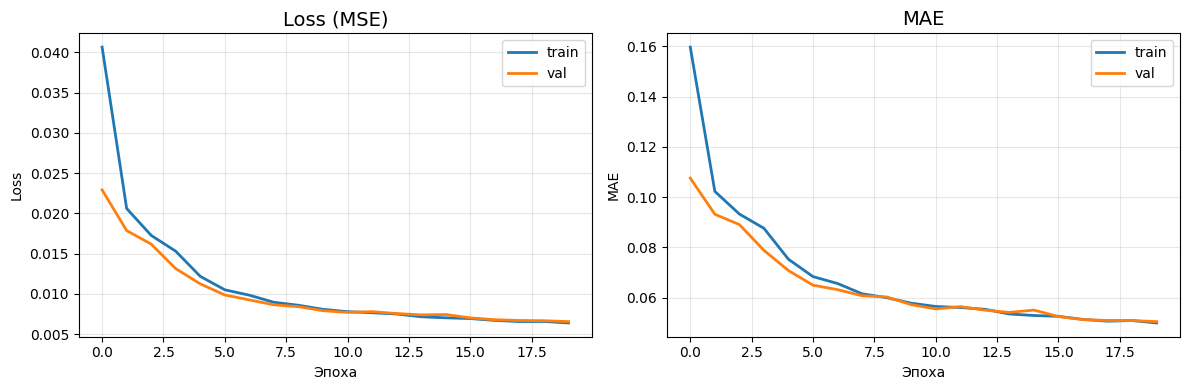

   Финальная Loss: 0.0064
   Финальная Val Loss: 0.0066


In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train', linewidth=2)
plt.plot(history.history['val_loss'], label='val', linewidth=2)
plt.title('Loss (MSE)', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train', linewidth=2)
plt.plot(history.history['val_mae'], label='val', linewidth=2)
plt.title('MAE', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"   Финальная Loss: {history.history['loss'][-1]:.4f}")
print(f"   Финальная Val Loss: {history.history['val_loss'][-1]:.4f}")

**3.7. Тестирование**

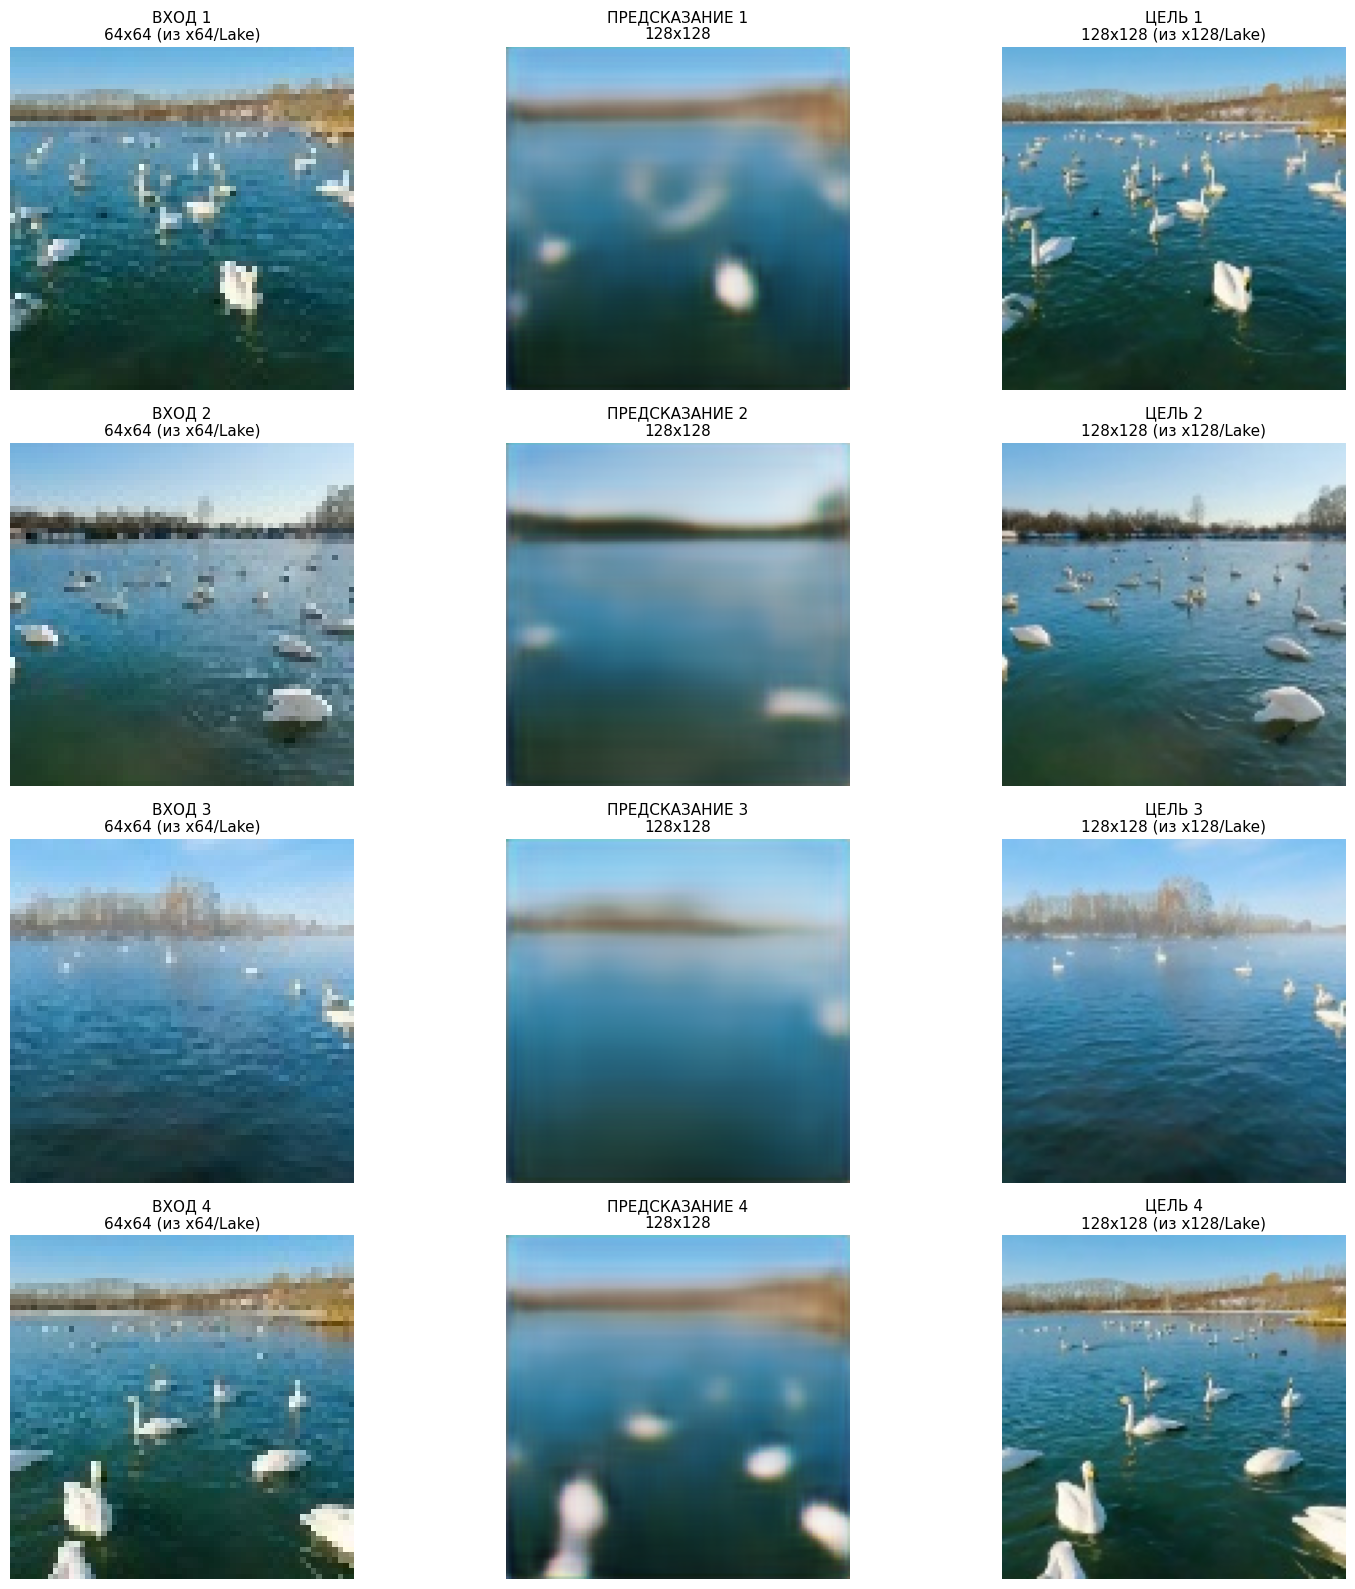

   Loss (MSE): 0.0067
   MAE: 0.0508


In [15]:
n = 4
idx = np.random.choice(len(X_low_test), n, replace=False)

# Предсказания
pred = model.predict(X_low_test[idx], verbose=0)

# Визуализация
plt.figure(figsize=(16, 4*n))

for i in range(n):
    # ВХОД - 64x64
    plt.subplot(n, 3, i*3 + 1)
    plt.imshow(X_low_test[idx[i]])
    plt.title(f'ВХОД {i+1}\n64x64 (из x64/Lake)', fontsize=11)
    plt.axis('off')

    # ПРЕДСКАЗАНИЕ - 128x128
    plt.subplot(n, 3, i*3 + 2)
    plt.imshow(pred[i])
    plt.title(f'ПРЕДСКАЗАНИЕ {i+1}\n128x128', fontsize=11)
    plt.axis('off')

    # ЦЕЛЬ - оригинал 128x128
    plt.subplot(n, 3, i*3 + 3)
    plt.imshow(X_high_test[idx[i]])
    plt.title(f'ЦЕЛЬ {i+1}\n128x128 (из x128/Lake)', fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Оценка на тесте
test_loss, test_mae = model.evaluate(X_low_test, X_high_test, verbose=0)
print(f"   Loss (MSE): {test_loss:.4f}")
print(f"   MAE: {test_mae:.4f}")

**3.6. Адаптация для произвольных размеров**

In [16]:
def upscale_image(img_path):
    """Увеличивает разрешение изображения с 64x64 до 128x128"""
    img = Image.open(img_path).convert('RGB')
    img_small = img.resize((IMG_LOW, IMG_LOW), Image.LANCZOS)

    x = np.expand_dims(np.array(img_small) / 255.0, axis=0)
    enhanced = model.predict(x, verbose=0)[0]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Оригинал")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_small)
    plt.title(f"Вход (64x64)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(enhanced)
    plt.title(f"Результат (128x128)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return enhanced

print(f"  - Обучалась на изображениях Lake")
print(f"  - Увеличивает 64x64 → 128x128")
print(f"  - Тестовая MAE: {test_mae:.4f}")

  - Обучалась на изображениях Lake
  - Увеличивает 64x64 → 128x128
  - Тестовая MAE: 0.0508
